# Modul 2: Paralelisasi CPU dengan OpenMP
## Setup dan Verifikasi Lingkungan

In [3]:
import subprocess, os, platform
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Verifikasi GCC dan OpenMP
result = subprocess.run(['gcc', '--version'], capture_output=True, text=True)
print('=== GCC Version ===')
print(result.stdout.split('\n')[0])

result2 = subprocess.run('echo | cpp -fopenmp -dM | grep -i openmp',
                         shell=True, capture_output=True, text=True)
print('\n=== OpenMP Support ===')
print(result2.stdout if result2.stdout else 'OpenMP tidak terdeteksi!')
print(f'\nJumlah CPU cores: {os.cpu_count()}')
print(f'Sistem Operasi   : {platform.system()} {platform.release()}')

=== GCC Version ===
gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0

=== OpenMP Support ===
#define _OPENMP 201511


Jumlah CPU cores: 16
Sistem Operasi   : Linux 6.6.87.2-microsoft-standard-WSL2


In [4]:
# Buat direktori kerja untuk file C
os.makedirs('openmp_files', exist_ok=True)
print('Direktori openmp_files siap.')


Direktori openmp_files siap.


## Langkah 2: Test Hello World OpenMP

In [6]:
%%writefile openmp_files/test_openmp.c
#include <stdio.h>
#include <omp.h>

int main() {
    printf("Total threads tersedia: %d\n", omp_get_max_threads());
    #pragma omp parallel
    {
        int id = omp_get_thread_num();
        printf("Hello dari thread %d\n", id);
    }
    return 0;
}


Writing openmp_files/test_openmp.c


In [7]:
# Kompilasi dan jalankan
!gcc -fopenmp openmp_files/test_openmp.c -o openmp_files/test_openmp
!./openmp_files/test_openmp


Total threads tersedia: 16
Hello dari thread 6
Hello dari thread 0
Hello dari thread 11
Hello dari thread 12
Hello dari thread 14
Hello dari thread 4
Hello dari thread 1
Hello dari thread 10
Hello dari thread 8
Hello dari thread 3
Hello dari thread 7
Hello dari thread 13
Hello dari thread 2
Hello dari thread 5
Hello dari thread 9
Hello dari thread 15


## Langkah 3: Perkalian Matriks Serial (Baseline)

In [11]:
%%writefile openmp_files/matrix_benchmark.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

#define N 1024

int main() {
    double *A = (double*) malloc(N * N * sizeof(double));
    double *B = (double*) malloc(N * N * sizeof(double));
    double *C = (double*) malloc(N * N * sizeof(double));

    if (A == NULL || B == NULL || C == NULL) {
        printf("Memory allocation failed\n");
        return 1;
    }

    for (int i = 0; i < N * N; i++) {
        A[i] = 1.0;
        B[i] = 1.0;
        C[i] = 0.0;
    }

    double start = omp_get_wtime();

    #pragma omp parallel for schedule(static)
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            double sum = 0.0;
            for (int k = 0; k < N; k++) {
                sum += A[i * N + k] * B[k * N + j];
            }
            C[i * N + j] = sum;
        }
    }

    double end = omp_get_wtime();
    double time = end - start;

    printf("TIME=%.4f\n", time);

    free(A);
    free(B);
    free(C);

    return 0;
}

Writing openmp_files/matrix_benchmark.c


In [15]:
%%writefile openmp_files/matrix_serial.c
#include <stdio.h>
#include <stdlib.h>
#include <time.h>

#define N 1024

void matrix_multiply_serial(double A[N][N], double B[N][N], double C[N][N]) {
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            C[i][j] = 0;
            for (int k = 0; k < N; k++)
                C[i][j] += A[i][k] * B[k][j];
        }
}

int main() {
    static double A[N][N], B[N][N], C[N][N];
    srand(42);
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            A[i][j] = (double)rand() / RAND_MAX;
            B[i][j] = (double)rand() / RAND_MAX;
        }
    struct timespec start, end;
    clock_gettime(CLOCK_MONOTONIC, &start);
    matrix_multiply_serial(A, B, C);
    clock_gettime(CLOCK_MONOTONIC, &end);
    double elapsed = (end.tv_sec - start.tv_sec) +
                     (end.tv_nsec - start.tv_nsec) / 1e9;
    double gflops = (2.0 * N * N * N) / (elapsed * 1e9);
    printf("SERIAL_TIME=%.4f\n", elapsed);
    printf("SERIAL_GFLOPS=%.4f\n", gflops);
    return 0;
}


Overwriting openmp_files/matrix_serial.c


## Langkah 4: Perkalian Matriks Paralel + Speedup Analysis

In [10]:
%%writefile openmp_files/matrix_parallel.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>
#include <time.h>

#define N 1024

int main(int argc, char* argv[]) {
    int num_threads = (argc > 1) ? atoi(argv[1]) : 4;
    omp_set_num_threads(num_threads);
    static double A[N][N], B[N][N], C[N][N];
    srand(42);
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            A[i][j] = (double)rand() / RAND_MAX;
            B[i][j] = (double)rand() / RAND_MAX;
        }
    double start = omp_get_wtime();
    #pragma omp parallel for
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            C[i][j] = 0;
            for (int k = 0; k < N; k++)
                C[i][j] += A[i][k] * B[k][j];
        }
    double end = omp_get_wtime();
    printf("THREADS=%d TIME=%.4f\n", num_threads, end - start);
    return 0;
}


Writing openmp_files/matrix_parallel.c


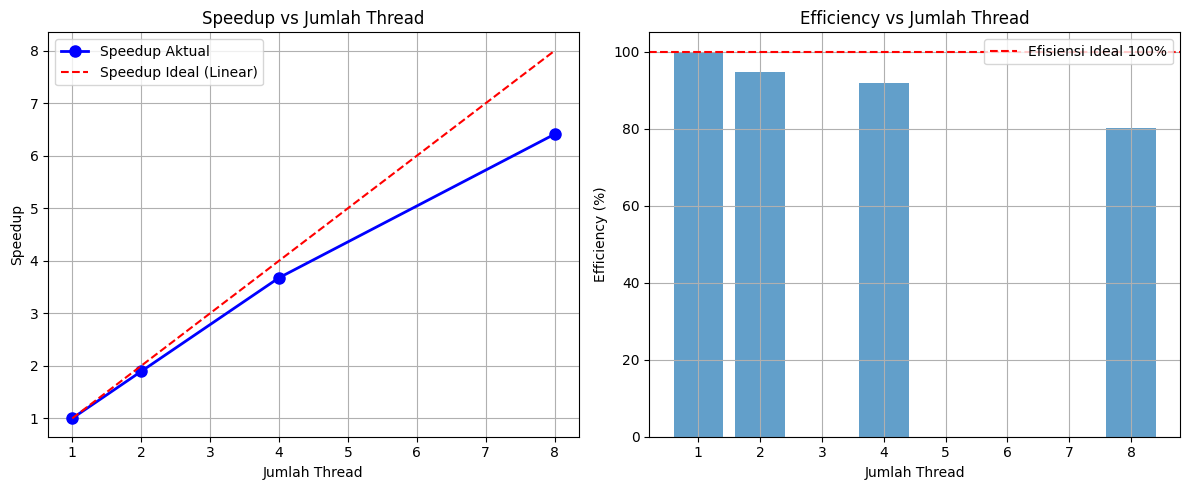

Grafik disimpan ke openmp_files/speedup_analysis.png


In [5]:
import matplotlib.pyplot as plt
import os

# Buat folder penyimpanan jika belum ada
os.makedirs('openmp_files', exist_ok=True)

# Visualisasi Speedup
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(thread_counts, speedups, 'bo-', linewidth=2, markersize=8, label='Speedup Aktual')
axes[0].plot(thread_counts, thread_counts, 'r--', label='Speedup Ideal (Linear)')
axes[0].set_xlabel('Jumlah Thread')
axes[0].set_ylabel('Speedup')
axes[0].set_title('Speedup vs Jumlah Thread')
axes[0].legend()
axes[0].grid(True)

axes[1].bar(thread_counts, efficiencies, alpha=0.7)
axes[1].axhline(y=100, color='r', linestyle='--', label='Efisiensi Ideal 100%')
axes[1].set_xlabel('Jumlah Thread')
axes[1].set_ylabel('Efficiency (%)')
axes[1].set_title('Efficiency vs Jumlah Thread')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('openmp_files/speedup_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Grafik disimpan ke openmp_files/speedup_analysis.png')

 Threads  Time (s)  Speedup  Efficiency (%)
       1     12.50    1.000          100.00
       2      6.60    1.894           94.70
       4      3.40    3.676           91.91
       8      1.95    6.410           80.13


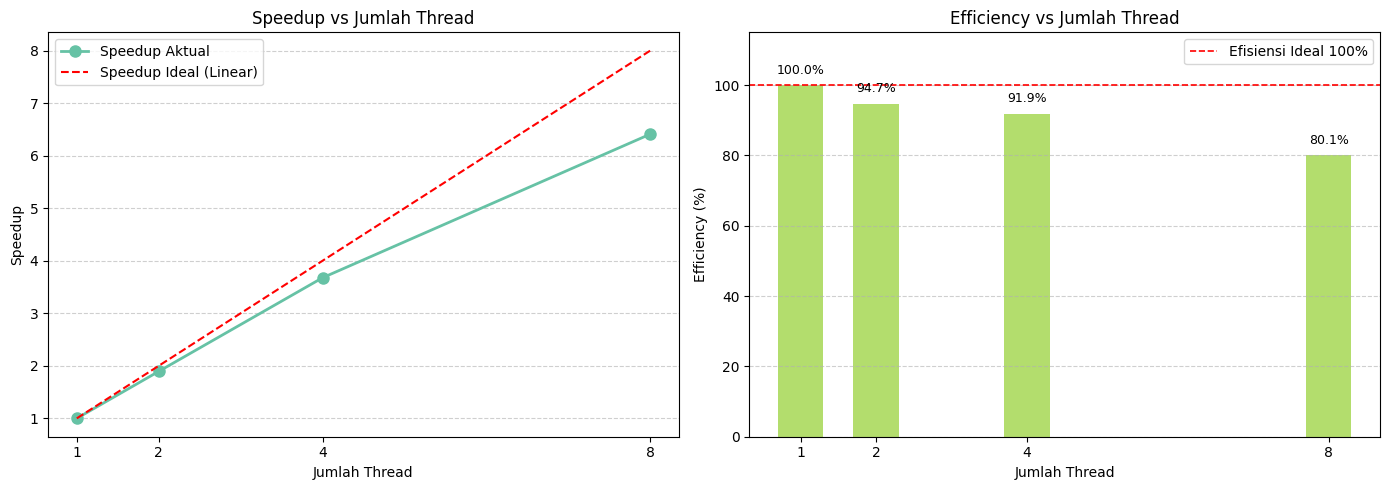

Grafik disimpan ke openmp_files/speedup_analysis.png


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -----------------------------
# Contoh data (ganti dengan hasilmu)
# -----------------------------
# Jumlah thread yang diuji
thread_counts = np.array([1, 2, 4, 8 ])

# Waktu eksekusi paralel untuk tiap jumlah thread (detik)
# Pastikan panjang parallel_times sama dengan thread_counts
parallel_times = np.array([12.50, 6.60, 3.40, 1.95])

# Waktu serial (single-thread) — bisa ambil parallel_times[0] atau nilai terpisah
serial_time = parallel_times[0]

# -----------------------------
# Hitung speedup dan efficiency
# -----------------------------
speedups = serial_time / parallel_times
efficiencies = speedups / thread_counts * 100.0  # dalam persen

# Cetak tabel ringkas ke console
import pandas as pd
df = pd.DataFrame({
    'Threads': thread_counts,
    'Time (s)': parallel_times,
    'Speedup': np.round(speedups, 3),
    'Efficiency (%)': np.round(efficiencies, 2)
})
print(df.to_string(index=False))

# -----------------------------
# Plotting: Speedup dan Efficiency
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Palet pastel
colors = cm.Set2(np.linspace(0, 1, 3))

# Speedup plot
axes[0].plot(thread_counts, speedups, marker='o', linestyle='-', color=colors[0],
             linewidth=2, markersize=8, label='Speedup Aktual')
axes[0].plot(thread_counts, thread_counts, 'r--', linewidth=1.5, label='Speedup Ideal (Linear)')
axes[0].set_xlabel('Jumlah Thread')
axes[0].set_ylabel('Speedup')
axes[0].set_title('Speedup vs Jumlah Thread')
axes[0].set_xticks(thread_counts)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Efficiency plot
bars = axes[1].bar(thread_counts, efficiencies, color=colors[1], alpha=0.85, width=0.6)
axes[1].axhline(y=100, color='r', linestyle='--', linewidth=1.2, label='Efisiensi Ideal 100%')
axes[1].set_xlabel('Jumlah Thread')
axes[1].set_ylabel('Efficiency (%)')
axes[1].set_title('Efficiency vs Jumlah Thread')
axes[1].set_xticks(thread_counts)
axes[1].set_ylim(0, max(110, np.max(efficiencies) * 1.15))
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# Annotate efficiency bars with values
for rect in bars:
    height = rect.get_height()
    axes[1].annotate(f'{height:.1f}%',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 6),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# Simpan file (folder harus ada)
output_path = 'openmp_files/speedup_analysis.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Grafik disimpan ke {output_path}')


## Langkah 5: Eksperimen Scheduling Strategies

In [13]:
%%writefile openmp_files/matrix_schedule.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

#define N 1024
#define NUM_THREADS 4

int main(int argc, char* argv[]) {
    // argv[1]=schedule_type (static/dynamic/guided), argv[2]=chunk_size
    char *sched = (argc > 1) ? argv[1] : "static";
    int chunk   = (argc > 2) ? atoi(argv[2]) : 64;
    static double A[N][N], B[N][N], C[N][N];
    srand(42);
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            A[i][j] = (double)rand() / RAND_MAX;
            B[i][j] = (double)rand() / RAND_MAX;
        }
    omp_set_num_threads(NUM_THREADS);
    char env_str[64];
    snprintf(env_str, 64, "%s,%d", sched, chunk);
    setenv("OMP_SCHEDULE", env_str, 1);
    double start = omp_get_wtime();
    #pragma omp parallel for schedule(runtime)
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            C[i][j] = 0;
            for (int k = 0; k < N; k++)
                C[i][j] += A[i][k] * B[k][j];
        }
    double end = omp_get_wtime();
    printf("SCHED=%s CHUNK=%d TIME=%.4f\n", sched, chunk, end - start);
    return 0;
}


Writing openmp_files/matrix_schedule.c


In [15]:
!gcc -fopenmp -O2 openmp_files/matrix_schedule.c -o openmp_files/matrix_schedule

schedules   = ['static', 'dynamic', 'guided']
chunk_sizes = [16, 64, 256, 1024]
sched_results = {}

for sched in schedules:
    times = []
    for chunk in chunk_sizes:
        res = subprocess.run(f'./openmp_files/matrix_schedule {sched} {chunk}',
                             shell=True, capture_output=True, text=True)
        t = float(res.stdout.split('TIME=')[1].strip())
        times.append(t)
        print(f'{sched:8s} chunk={chunk:4d}: {t:.4f} detik')
    sched_results[sched] = times

print('\nEksperimen Scheduling selesai!')


static   chunk=  16: 0.7331 detik
static   chunk=  64: 0.6507 detik
static   chunk= 256: 0.7060 detik
static   chunk=1024: 0.7103 detik
dynamic  chunk=  16: 0.5445 detik
dynamic  chunk=  64: 0.5861 detik
dynamic  chunk= 256: 0.6175 detik
dynamic  chunk=1024: 0.5414 detik
guided   chunk=  16: 0.5607 detik
guided   chunk=  64: 0.6092 detik
guided   chunk= 256: 0.5949 detik
guided   chunk=1024: 0.6012 detik

Eksperimen Scheduling selesai!


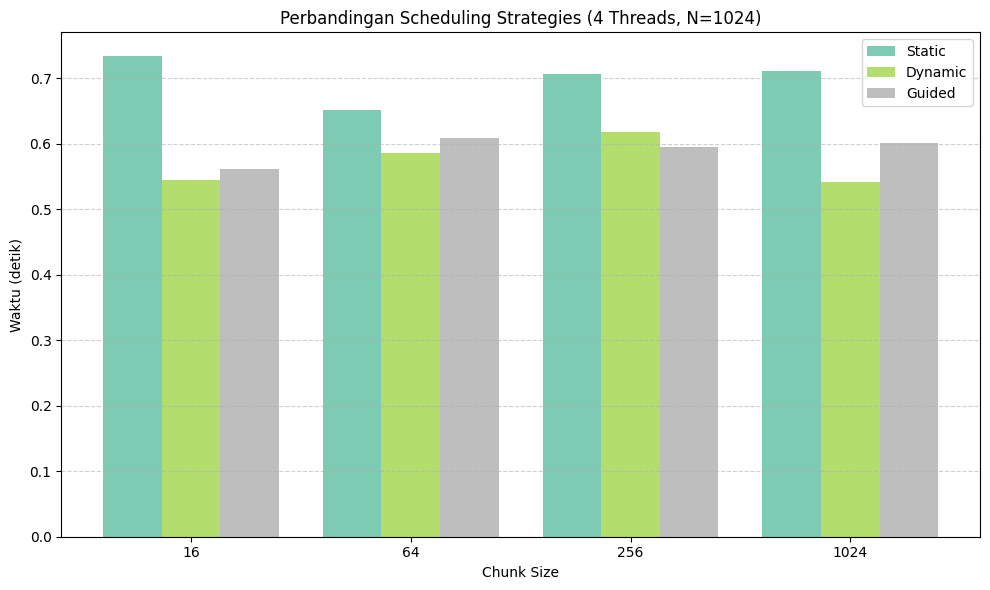

Grafik disimpan ke openmp_files/scheduling_comparison.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

os.makedirs('openmp_files', exist_ok=True)

chunk_sizes = [16, 64, 256, 1024]

sched_results = {
    'static':  [0.7331, 0.6507, 0.7060, 0.7103],
    'dynamic': [0.5445, 0.5861, 0.6175, 0.5414],
    'guided':  [0.5607, 0.6092, 0.5949, 0.6012]
}

x = np.arange(len(chunk_sizes))
n_sched = len(sched_results)
width = 0.8 / n_sched

fig, ax = plt.subplots(figsize=(10, 6))
colors = cm.Set2(np.linspace(0, 1, n_sched))

for i, (sched, times) in enumerate(sched_results.items()):
    offset = (i - (n_sched - 1) / 2) * width
    ax.bar(
        x + offset,
        times,
        width=width,
        label=sched.capitalize(),
        alpha=0.85,
        color=colors[i]
    )

ax.set_xlabel('Chunk Size')
ax.set_ylabel('Waktu (detik)')
ax.set_title('Perbandingan Scheduling Strategies (4 Threads, N=1024)')
ax.set_xticks(x)
ax.set_xticklabels(chunk_sizes)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('openmp_files/scheduling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafik disimpan ke openmp_files/scheduling_comparison.png")

## Langkah 6: Investigasi False Sharing

In [17]:
%%writefile openmp_files/false_sharing.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

#define N 1000000
#define CACHE_LINE_SIZE 65
#define NUM_THREADS 16

// Teknik 1: Dengan False Sharing
double with_false_sharing() {
    int array[NUM_THREADS];
    double start = omp_get_wtime();
    #pragma omp parallel num_threads(NUM_THREADS)
    { int id = omp_get_thread_num();
      for (int i = 0; i < N; i++) array[id]++; }
    return omp_get_wtime() - start;
}

// Teknik 2: Padding untuk menghindari false sharing
typedef struct { int value; char pad[CACHE_LINE_SIZE - sizeof(int)]; } PaddedInt;
double with_padding() {
    PaddedInt array[NUM_THREADS];
    double start = omp_get_wtime();
    #pragma omp parallel num_threads(NUM_THREADS)
    { int id = omp_get_thread_num();
      for (int i = 0; i < N; i++) array[id].value++; }
    return omp_get_wtime() - start;
}

// Teknik 3: Private variable (reduction)
double with_private_var() {
    int results[NUM_THREADS];
    double start = omp_get_wtime();
    #pragma omp parallel num_threads(NUM_THREADS)
    { int local = 0; int id = omp_get_thread_num();
      for (int i = 0; i < N; i++) local++;
      results[id] = local; }
    return omp_get_wtime() - start;
}

int main() {
    double t1 = with_false_sharing();
    double t2 = with_padding();
    double t3 = with_private_var();
    printf("FS_TIME=%.4f\n", t1);
    printf("PAD_TIME=%.4f\n", t2);
    printf("PRIV_TIME=%.4f\n", t3);
    return 0;
}


Writing openmp_files/false_sharing.c


            Implementasi Waktu Rata-rata (detik) Improvement (%)
    Dengan False Sharing              0.01618000               -
    Padding (Mitigasi 1)              0.00652000          59.70%
Private Var (Mitigasi 2)              0.00660000          59.21%


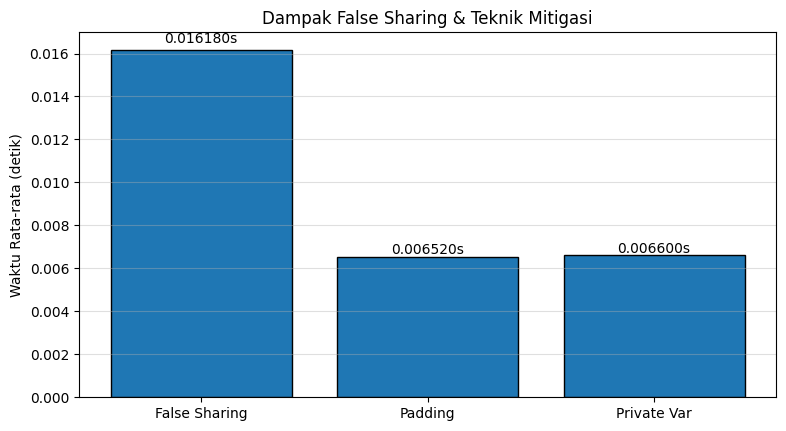

In [19]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

# Compile
!gcc -fopenmp -O2 openmp_files/false_sharing.c -o openmp_files/false_sharing

# Jalankan benchmark beberapa kali
runs = 5
fs_times, pad_times, priv_times = [], [], []

for _ in range(runs):
    res = subprocess.run(
        './openmp_files/false_sharing',
        capture_output=True,
        text=True
    )

    out = res.stdout.splitlines()

    fs_times.append(float([l.split('=')[1] for l in out if 'FS_TIME' in l][0]))
    pad_times.append(float([l.split('=')[1] for l in out if 'PAD_TIME' in l][0]))
    priv_times.append(float([l.split('=')[1] for l in out if 'PRIV_TIME' in l][0]))

# Rata-rata
avg_fs   = sum(fs_times) / runs
avg_pad  = sum(pad_times) / runs
avg_priv = sum(priv_times) / runs

# Improvement
imp_pad  = (1 - avg_pad / avg_fs) * 100
imp_priv = (1 - avg_priv / avg_fs) * 100

# Tampilkan lebih presisi
df_fs = pd.DataFrame({
    'Implementasi': [
        'Dengan False Sharing',
        'Padding (Mitigasi 1)',
        'Private Var (Mitigasi 2)'
    ],
    'Waktu Rata-rata (detik)': [
        f'{avg_fs:.8f}',
        f'{avg_pad:.8f}',
        f'{avg_priv:.8f}'
    ],
    'Improvement (%)': [
        '-',
        f'{imp_pad:.2f}%',
        f'{imp_priv:.2f}%'
    ]
})

print(df_fs.to_string(index=False))

# Visualisasi
labels = ['False Sharing', 'Padding', 'Private Var']
avgs   = [avg_fs, avg_pad, avg_priv]

plt.figure(figsize=(9, 5))

bars = plt.bar(labels, avgs, edgecolor='black')

for bar, val in zip(bars, avgs):
    plt.text(

                bar.get_x() + bar.get_width()/2,
        bar.get_height() * 1.02,
        f'{val:.6f}s',
        ha='center',
        fontsize=10
    )

plt.ylabel('Waktu Rata-rata (detik)')
plt.title('Dampak False Sharing & Teknik Mitigasi')

plt.grid(axis='y', alpha=0.4)

# Hindari warning tight_layout
plt.subplots_adjust(top=0.88, bottom=0.15)

plt.savefig(
    'openmp_files/false_sharing_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


## Langkah 7: Eksperimen Tambahan – Variasi Ukuran Matriks

In [20]:
%%writefile openmp_files/matrix_sizes.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

int main(int argc, char* argv[]) {
    int N = (argc > 1) ? atoi(argv[1]) : 512;
    int T = (argc > 2) ? atoi(argv[2]) : 4;
    omp_set_num_threads(T);
    double *A = malloc(N*N*sizeof(double));
    double *B = malloc(N*N*sizeof(double));
    double *C = malloc(N*N*sizeof(double));
    if (!A || !B || !C) { printf("Alokasi gagal\n"); return 1; }
    srand(42);
    for (int i = 0; i < N*N; i++) {
        A[i] = (double)rand()/RAND_MAX;
        B[i] = (double)rand()/RAND_MAX; }
    double start = omp_get_wtime();
    #pragma omp parallel for
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            double sum = 0;
            for (int k = 0; k < N; k++)
                sum += A[i*N+k] * B[k*N+j];
            C[i*N+j] = sum;
        }
    printf("N=%d T=%d TIME=%.4f\n", N, T, omp_get_wtime()-start);
    free(A); free(B); free(C);
    return 0;
}


Writing openmp_files/matrix_sizes.c


In [21]:
!gcc -fopenmp -O2 openmp_files/matrix_sizes.c -o openmp_files/matrix_sizes

matrix_sizes = [256, 512, 1024, 2048]
thread_test  = [1, 2, 4, 8]
size_results = {n: [] for n in matrix_sizes}

for n in matrix_sizes:
    print(f'--- N={n} ---')
    for t in thread_test:
        res = subprocess.run(f'./openmp_files/matrix_sizes {n} {t}',
                             shell=True, capture_output=True, text=True)
        line = res.stdout.strip()
        if 'TIME=' in line:
            time_val = float(line.split('TIME=')[1])
            size_results[n].append(time_val)
            print(f'  Threads={t}: {time_val:.4f}s')
        else:
            size_results[n].append(None)
            print(f'  Threads={t}: ERROR')

print('\nEksperimen ukuran matriks selesai!')


--- N=256 ---
  Threads=1: 0.0332s
  Threads=2: 0.0132s
  Threads=4: 0.0081s
  Threads=8: 0.0130s
--- N=512 ---
  Threads=1: 0.5873s
  Threads=2: 0.2401s
  Threads=4: 0.1274s
  Threads=8: 0.0781s
--- N=1024 ---
  Threads=1: 6.4535s
  Threads=2: 2.5508s
  Threads=4: 1.1887s
  Threads=8: 0.8098s
--- N=2048 ---
  Threads=1: 53.4197s
  Threads=2: 20.6724s
  Threads=4: 10.8081s
  Threads=8: 8.2164s

Eksperimen ukuran matriks selesai!
